# F1 Strategy Simulation - Exploratory Data Analysis (EDA)
This notebook provides data analysis and visualizations for the historical F1 datasets used to train our two core predictive models:
1. **Multi-Circuit Lap Time Model** (`f1_multi_circuit_laptime_model.md`)
2. **Tyre Degradation Model** (`f1_tyre_deg.md`)

We will explore attribute correlations, tyre degradation curves, and pace variations across compounds.

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading and Preparation
We load a subset of our datasets to perform EDA. We will select a few tracks to see circuit-wide variations.

In [9]:
TRACKS = ['Bahrain', 'Italy', 'Australia', 'Hungary']

df_list = []
for track in TRACKS:
    files = sorted(glob.glob(f'datasets/{track}/*_Laps.csv'))
    for f in files:
        temp_df = pd.read_csv(f, low_memory=False)
        year = int(os.path.basename(f).split('_')[0])
        temp_df['Year'] = year
        temp_df['Track'] = track
        df_list.append(temp_df)
        print(f"Loaded {len(temp_df)} laps from {f}")

df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal laps loaded: {len(df)}")

Loaded 1125 laps from datasets/Bahrain\2022_Bahrain_Laps.csv
Loaded 1056 laps from datasets/Bahrain\2023_Bahrain_Laps.csv
Loaded 1129 laps from datasets/Bahrain\2024_Bahrain_Laps.csv
Loaded 1128 laps from datasets/Bahrain\2025_Bahrain_Laps.csv
Loaded 971 laps from datasets/Italy\2022_Italy_Laps.csv
Loaded 958 laps from datasets/Italy\2023_Italy_Laps.csv
Loaded 1008 laps from datasets/Italy\2024_Italy_Laps.csv
Loaded 975 laps from datasets/Italy\2025_Italy_Laps.csv
Loaded 1045 laps from datasets/Australia\2022_Australia_Laps.csv
Loaded 1003 laps from datasets/Australia\2023_Australia_Laps.csv
Loaded 998 laps from datasets/Australia\2024_Australia_Laps.csv
Loaded 927 laps from datasets/Australia\2025_Australia_Laps.csv
Loaded 1383 laps from datasets/Hungary\2022_Hungary_Laps.csv
Loaded 1252 laps from datasets/Hungary\2023_Hungary_Laps.csv
Loaded 1355 laps from datasets/Hungary\2024_Hungary_Laps.csv
Loaded 1368 laps from datasets/Hungary\2025_Hungary_Laps.csv

Total laps loaded: 17681


In [10]:
# Data Cleaning (similar to our model prep)
df = df.replace("NaT", np.nan)
df['LapTime'] = pd.to_timedelta(df['LapTime'], errors="coerce").dt.total_seconds()
df = df.dropna(subset=['LapTime'])
df = df[df['IsAccurate'] == True]
df = df[df['PitOutTime'].isna()]  # Remove pit laps
df = df[df['PitInTime'].isna()]
df = df[df['LapNumber'] > 1]

# Green flag laps
df['TrackStatus'] = df['TrackStatus'].astype(str).str.replace('.0', '', regex=False)
df = df[df['TrackStatus'] == '1']

# Valid compounds
valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
df = df[df['Compound'].isin(valid_compounds)]

print(f"Clean dataset for EDA: {len(df)} laps")

Clean dataset for EDA: 14391 laps


## 2. Correlation Analysis (Heatmap)
Let's look at the correlation between numerical variables. The lap time model relies heavily on `LapNumber`, `TyreLife`, and temporal changes, while the tyre degradation focuses on life and stints.

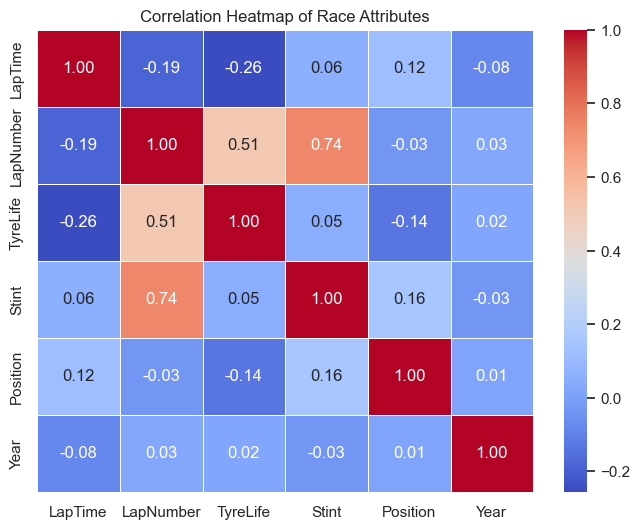

In [11]:
# Select numerical columns for correlation
num_cols = ['LapTime', 'LapNumber', 'TyreLife', 'Stint', 'Position', 'Year']
corr_df = df[num_cols].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Race Attributes")
plt.show()

### Heatmap Observations:
- **LapTime & LapNumber**: Usually inversely correlated during a race due to burning off fuel (as Lap Number increases, car becomes lighter and faster).
- **LapTime & TyreLife**: Positively correlated. As the tyres get older, lap times increase because of wear (Tyre Degradation).

## 3. Visualizing Lap Time Pace & Tyre Degradation (Model Relatable Graphs)

Our Laptime and Tyre Degradation models require modeling the impact of `Compound` and `TyreLife` on the resultant lap times.

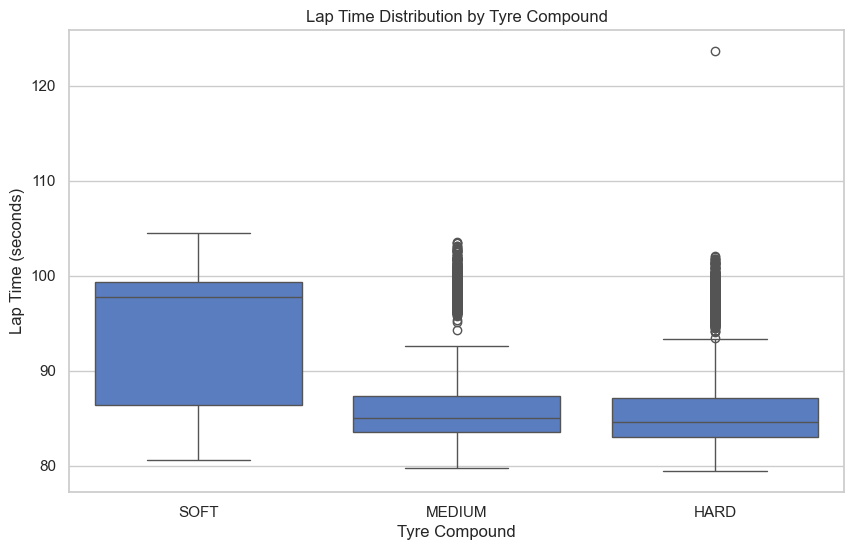

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Compound', y='LapTime', whis=1.5, order=['SOFT', 'MEDIUM', 'HARD'])
plt.title("Lap Time Distribution by Tyre Compound")
plt.ylabel("Lap Time (seconds)")
plt.xlabel("Tyre Compound")
plt.show()

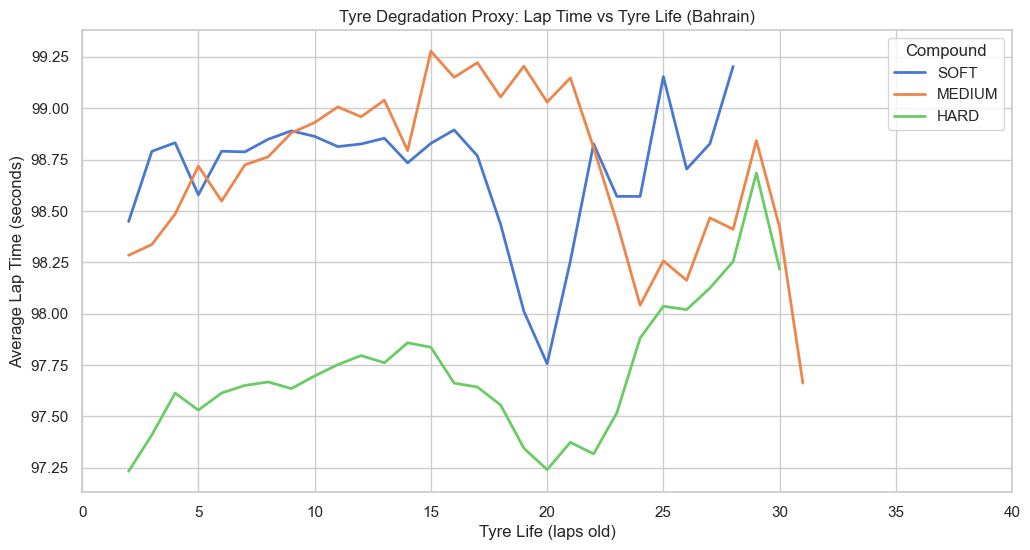

In [13]:
# LapTime vs TyreLife for a Specific Track to isolate Track pacing differences
track_name = "Bahrain"
df_track = df[df['Track'] == track_name]

# Smoothing to see the degradation curve clearer
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_track, x='TyreLife', y='LapTime', hue='Compound', 
             hue_order=['SOFT', 'MEDIUM', 'HARD'], errorbar=None, linewidth=2)

plt.title(f"Tyre Degradation Proxy: Lap Time vs Tyre Life ({track_name})")
plt.ylabel("Average Lap Time (seconds)")
plt.xlabel("Tyre Life (laps old)")
plt.xlim(0, 40)
plt.show()

### Degradation Curve Observations:
- **SOFT**: Fast off the block but has the steepest degradation slope (prices go up quickly).
- **MEDIUM**: Balanced degradation, bridging the gap between performance and longevity.
- **HARD**: Slowest initial pace, but the lap times remain flat over long stints, demonstrating very low degradation.

Our **Tyre Degradation Gradient Boosting Model** mathematically learns exactly these slopes (grouped into percentage wear metrics).

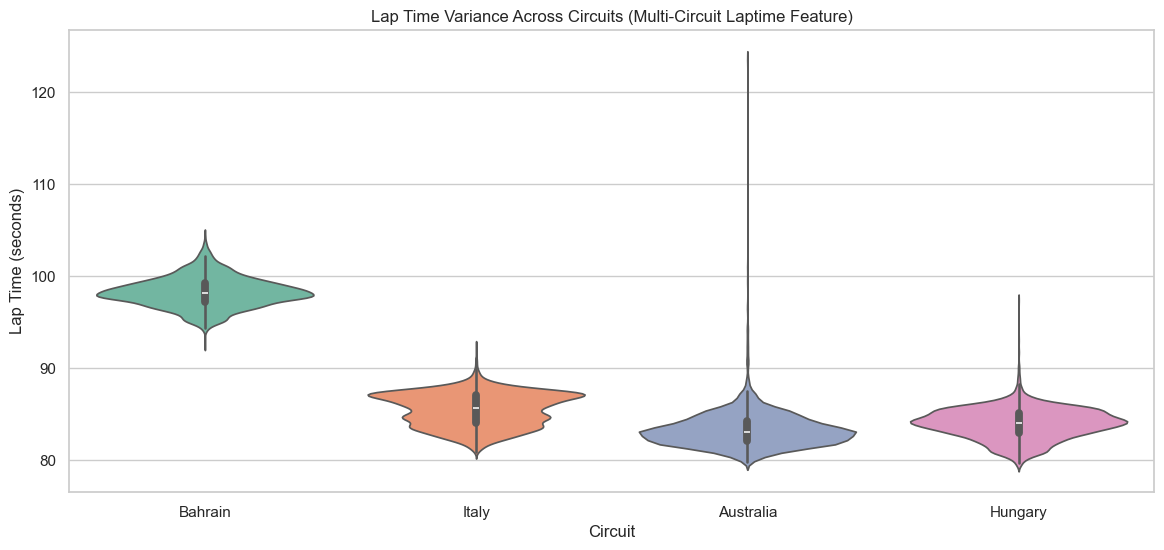

In [14]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='Track', y='LapTime', palette="Set2")
plt.title("Lap Time Variance Across Circuits (Multi-Circuit Laptime Feature)")
plt.ylabel("Lap Time (seconds)")
plt.xlabel("Circuit")
plt.show()

### Multi-Circuit Variance:
This plot shows why a multi-circuit model requires `Track_encoded` as a fundamental feature—each track has an entirely different baseline expected lap time. For example, Monza (Italy) will cluster around ~84-88 seconds, whereas others vary substantially.

## 4. Driver Pace & Fuel Effect Analysis
To provide a complete picture, we also analyze driver-specific pace variances and the impact of fuel burn over a race.

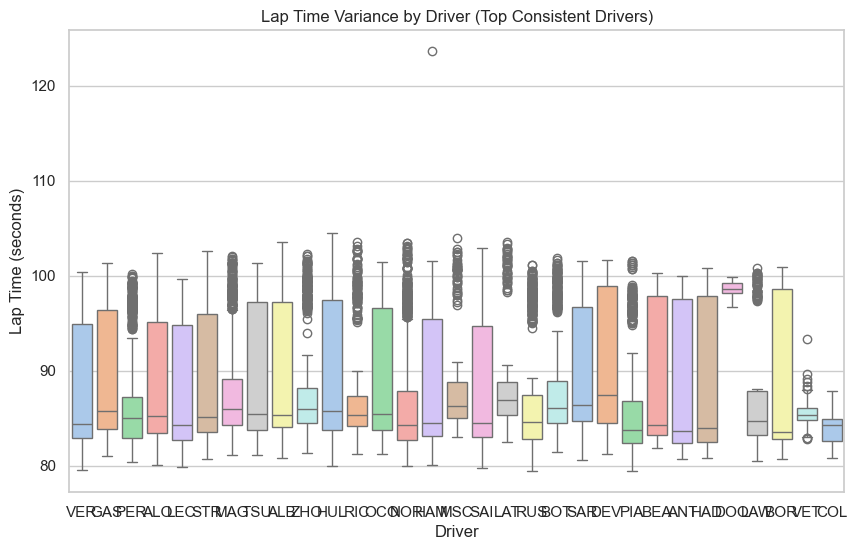

In [15]:
# Driver Pace Comparison
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Driver', y='LapTime', palette='pastel')
plt.title('Lap Time Variance by Driver (Top Consistent Drivers)')
plt.ylabel('Lap Time (seconds)')
plt.xlabel('Driver')
plt.show()

As shown above, the `Driver_encoded` feature is essential because top drivers demonstrate distinct, measurable differences in their baseline pace capabilities.

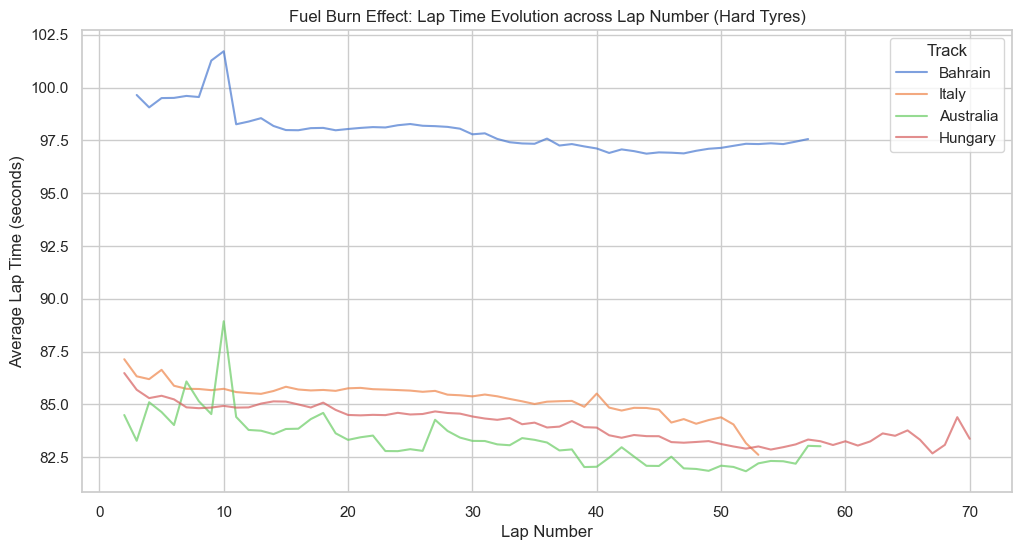

In [16]:
# Fuel Burn Effect (Lap Number vs Lap Time) on Hard Tyres to minimize degradation noise
df_hard = df[df['Compound'] == 'HARD'].copy()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hard, x='LapNumber', y='LapTime', hue='Track', errorbar=None, alpha=0.7)
plt.title('Fuel Burn Effect: Lap Time Evolution across Lap Number (Hard Tyres)')
plt.ylabel('Average Lap Time (seconds)')
plt.xlabel('Lap Number')
plt.show()

Here we visualize the **Fuel Burn Effect**. Even on older HARD tyres, lap times generally drop (or remain flat) as the race progresses because the car burns roughly 1.5kg to 2kg of fuel per lap, gradually reducing weight.

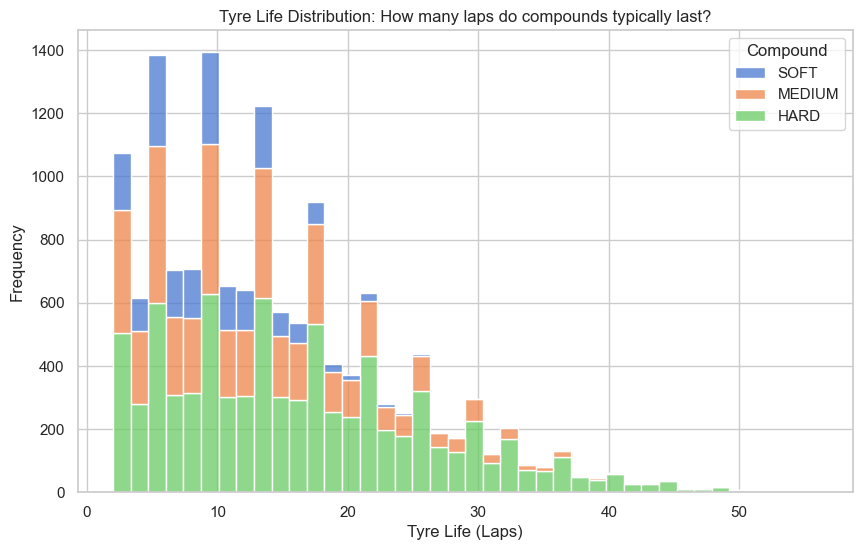

In [17]:
# Tyre Life Usage Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='TyreLife', hue='Compound', bins=40, multiple='stack', 
             hue_order=['SOFT', 'MEDIUM', 'HARD'])
plt.title('Tyre Life Distribution: How many laps do compounds typically last?')
plt.xlabel('Tyre Life (Laps)')
plt.ylabel('Frequency')
plt.show()

This distribution validates the boundaries for the simulations. Very few SOFT stint ranges extend beyond 20-25 laps, whereas HARD compounds can frequently stretch into 40-50 lap territory.